In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\User\Desktop\New folder\credit_risk_dataset.csv')


In [2]:
print(df.shape)        # neçə sətir, neçə sütun
print(df.head())       # ilk 5 sətir
print(df.info())       # sütunların tipi
print(df.isnull().sum()) # boş dəyərlər


(32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                   

In [3]:
# Düzgün sintaksis
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Yoxla
print(df.isnull().sum())
print(df['loan_status'].value_counts())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Mətn sütunlarını rəqəmə çevir
text_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

# X = giriş, y = hədəf
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print(X.shape)
print(X.head())

(32581, 11)
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0            4           3      35000          16.02                 0.59   
1            1           1       1000          11.14                 0.10   
2            3           2       5500          12.87                 0.57   
3            3           2      35000          15.23                 0.53   
4            3           2      35000          14.27                 0.55   

   cb_person_default_on_file  cb_person_cred_hist_length  
0                    

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Datanı train və test hissələrinə böl (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Modeli qur
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli öyrət
model.fit(X_train, y_train)

# Test datası üzərində proqnoz ver
y_pred = model.predict(X_test)

# Nəticəni qiymətləndir
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print(classification_report(y_test, y_pred))

Train: (26064, 11), Test: (6517, 11)
Accuracy: 92.97%
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



                       feature  importance
8          loan_percent_income    0.229651
1                person_income    0.147702
7                loan_int_rate    0.111537
5                   loan_grade    0.110818
2        person_home_ownership    0.099221
4                  loan_intent    0.074052
6                    loan_amnt    0.072906
3            person_emp_length    0.064608
0                   person_age    0.043978
10  cb_person_cred_hist_length    0.034884
9    cb_person_default_on_file    0.010643


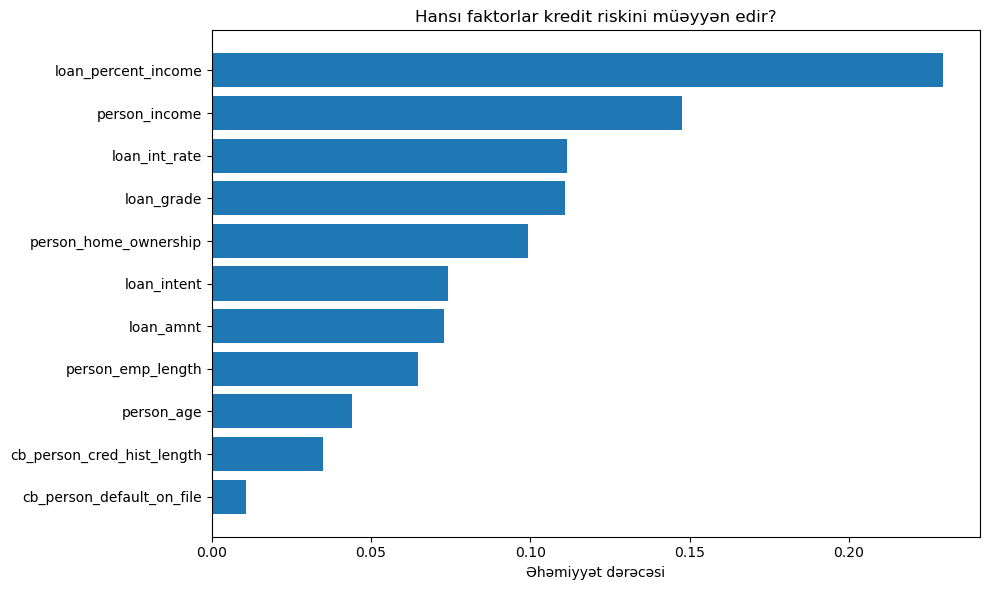

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Hansı sütun modelin qərarına daha çox təsir edir
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Vizuallaşdır
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Əhəmiyyət dərəcəsi')
plt.title('Hansı faktorlar kredit riskini müəyyən edir?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
# Təmiz datanı export et
df_clean = df.copy()

df_clean.to_csv(r'C:\Users\User\Desktop\New folder\credit_risk_clean.csv', index=False)

# Feature importance cədvəlini də export et
feature_importance.to_csv(r'C:\Users\User\Desktop\New folder\feature_importance.csv', index=False)

print("Fayllar hazırdır!")

Fayllar hazırdır!


In [8]:
# Orijinal dataseti yenidən yüklə
df_original = pd.read_csv(r'C:\Users\User\Desktop\New folder\credit_risk_dataset.csv', )

# Təmizlə
df_original['person_emp_length'] = df_original['person_emp_length'].fillna(df_original['person_emp_length'].median())
df_original['loan_int_rate'] = df_original['loan_int_rate'].fillna(df_original['loan_int_rate'].median())

# loan_intent orijinal mətn kimi qalsın, loan_status əlavə et
df_viz = df_original[['loan_intent', 'loan_status', 'person_income', 
                        'loan_amnt', 'loan_percent_income', 'loan_grade']].copy()

df_viz.to_csv(r'C:\Users\User\Desktop\New folder\credit_risk_viz.csv', index=False)

print("Hazırdır!")

Hazırdır!
